In [1]:
from dataclasses import dataclass
from pathlib import Path
import io
import re

import pandas as pd
import zstandard as zstd

In [2]:
@dataclass
class PgnGame:
  game_index: int
  tags: dict
  movetext: str
  raw_pgn: str

In [3]:
class PgnZstParser:
  def __init__(self, path):
    self.path = Path(path)

  def parse_first_n_with_eval(self, n_games):
    eval_games = []
    n_scanned = 0

    for game_lines in self._iter_raw_game_lines():
      raw_pgn = "\n".join(game_lines).strip()
      has_eval = "%eval" in raw_pgn

      if has_eval:
        game = self._build_game(
          game_index=n_scanned,
          game_lines=game_lines,
        )
        eval_games.append(game)

      n_scanned += 1

      if len(eval_games) >= n_games:
        break

    scan_report = {
      "n_requested_eval_games": n_games,
      "n_eval_games_found": len(eval_games),
      "n_total_games_scanned": n_scanned,
    }

    return eval_games, scan_report

  def _iter_raw_game_lines(self):
    game_lines = []
    seen_movetext = False

    with open(self.path, "rb") as file:
      dctx = zstd.ZstdDecompressor()

      with dctx.stream_reader(file) as byte_stream:
        text_stream = io.TextIOWrapper(
          byte_stream,
          encoding="utf-8",
          errors="replace",
        )

        for line in text_stream:
          line = line.rstrip("\n")

          if self._is_new_game_start(
            line=line,
            game_lines=game_lines,
            seen_movetext=seen_movetext,
          ):
            yield game_lines
            game_lines = []
            seen_movetext = False

          game_lines.append(line)

          if self._is_movetext_line(line):
            seen_movetext = True

        if game_lines:
          yield game_lines

  def _is_new_game_start(self, line, game_lines, seen_movetext):
    if not game_lines:
      return False

    if not seen_movetext:
      return False

    return line.startswith("[Event ")

  def _is_movetext_line(self, line):
    if not line.strip():
      return False

    if line.startswith("[") and line.endswith("]"):
      return False

    return True

  def _build_game(self, game_index, game_lines):
    raw_pgn = "\n".join(game_lines).strip()
    tags = {}
    movetext_lines = []
    in_movetext = False

    for line in game_lines:
      if self._is_tag_line(line) and not in_movetext:
        key, value = self._parse_tag_line(line)
        tags[key] = value
        continue

      if line.strip():
        in_movetext = True

      if in_movetext:
        movetext_lines.append(line)

    movetext = "\n".join(movetext_lines).strip()

    return PgnGame(
      game_index=game_index,
      tags=tags,
      movetext=movetext,
      raw_pgn=raw_pgn,
    )

  def _is_tag_line(self, line):
    return bool(re.match(r'^\[[A-Za-z0-9_]+ ".*"\]$', line))

  def _parse_tag_line(self, line):
    match = re.match(r'^\[([A-Za-z0-9_]+) "(.*)"\]$', line)

    if match is None:
      raise ValueError(f"Could not parse tag line: {line}")

    return match.group(1), match.group(2)

In [4]:
pgn_path = "../data/raw/lichess_db_standard_rated_2017-05.pgn.zst"
n_eval_games = 10

parser = PgnZstParser(pgn_path)

eval_games, scan_report = parser.parse_first_n_with_eval(
  n_games=n_eval_games,
)

scan_report

{'n_requested_eval_games': 10,
 'n_eval_games_found': 10,
 'n_total_games_scanned': 225}

In [5]:
TOKEN_PATTERN = re.compile(r"\{[^}]*\}|\S+")
EVAL_PATTERN = re.compile(r"\[%eval\s+([^\]]+)\]")
CLOCK_PATTERN = re.compile(r"\[%clk\s+([^\]]+)\]")

MOVE_NUMBER_PATTERN = re.compile(r"^\d+\.(?:\.\.)?$")
NAG_PATTERN = re.compile(r"^\$\d+$")

RESULT_TOKENS = {
  "1-0",
  "0-1",
  "1/2-1/2",
  "*",
}

## Parser helper functions

In [7]:
# Raw evaluation parsing
def parse_eval_raw(eval_raw):
  if eval_raw is None:
    return {
      "eval_pawns": None,
      "is_mate_eval": False,
      "mate_distance": None,
    }

  value = eval_raw.strip()

  if value.startswith("#"):
    mate_text = value.replace("#", "")

    return {
      "eval_pawns": None,
      "is_mate_eval": True,
      "mate_distance": int(mate_text),
    }

  eval_pawns = float(value)

  return {
    "eval_pawns": eval_pawns,
    "is_mate_eval": False,
    "mate_distance": None,
  }


# Clock parsing
def parse_clock_seconds(clock_raw):
  if clock_raw is None:
    return None

  pieces = clock_raw.strip().split(":")

  if len(pieces) == 3:
    hours = int(pieces[0])
    minutes = int(pieces[1])
    seconds = float(pieces[2])

    return 3600 * hours + 60 * minutes + seconds

  if len(pieces) == 2:
    minutes = int(pieces[0])
    seconds = float(pieces[1])

    return 60 * minutes + seconds

  return float(clock_raw)

## Move token helper functions

In [8]:
def is_comment_token(token):
  return token.startswith("{") and token.endswith("}")


def is_move_number_token(token):
  return bool(MOVE_NUMBER_PATTERN.match(token))


def is_result_token(token):
  return token in RESULT_TOKENS


def is_nag_token(token):
  return bool(NAG_PATTERN.match(token))


def is_skip_token(token):
  if is_move_number_token(token):
    return True

  if is_result_token(token):
    return True

  if is_nag_token(token):
    return True

  return False

## Extract one game into per-ply rows

This is the central extraction function.

It walks through the movetext token-by-token. When it sees a move, it creates
a row. When it sees a comment after a move, it attaches eval/clock information
to that most recent move.

In [11]:
def extract_ply_rows_from_game(game):
  rows = []
  current_row_idx = None
  ply = 0

  tokens = TOKEN_PATTERN.findall(game.movetext)

  for token in tokens:
    if is_comment_token(token):
      if current_row_idx is None:
        continue

      comment_raw = token

      eval_matches = EVAL_PATTERN.findall(comment_raw)
      clock_matches = CLOCK_PATTERN.findall(comment_raw)

      eval_raw = eval_matches[0] if eval_matches else None
      clock_raw = clock_matches[0] if clock_matches else None

      eval_parts = parse_eval_raw(eval_raw)
      clock_seconds = parse_clock_seconds(clock_raw)

      rows[current_row_idx]["comment_raw"] = comment_raw
      rows[current_row_idx]["eval_raw"] = eval_raw
      rows[current_row_idx]["clock_raw"] = clock_raw
      rows[current_row_idx]["clock_seconds"] = clock_seconds

      rows[current_row_idx].update(eval_parts)

      continue

    if is_skip_token(token):
      continue

    ply += 1

    side = "white" if ply % 2 == 1 else "black"
    move_number = (ply + 1) // 2

    row = {
      "game_index": game.game_index,
      "ply": ply,
      "move_number": move_number,
      "side": side,
      "san_raw": token,
      "comment_raw": None,
      "eval_raw": None,
      "eval_pawns": None,
      "is_mate_eval": False,
      "mate_distance": None,
      "clock_raw": None,
      "clock_seconds": None,
    }

    rows.append(row)
    current_row_idx = len(rows) - 1

  return rows

## Extract game-level metadata

In [12]:
def safe_int(value):
  if value is None:
    return None

  try:
    return int(value)
  except ValueError:
    return None


def parse_result_for_white(result):
  if result == "1-0":
    return 1.0

  if result == "0-1":
    return 0.0

  if result == "1/2-1/2":
    return 0.5

  return None


def parse_time_control(time_control):
  if time_control is None:
    return {
      "time_base_seconds": None,
      "time_increment_seconds": None,
    }

  if "+" not in time_control:
    return {
      "time_base_seconds": None,
      "time_increment_seconds": None,
    }

  base, increment = time_control.split("+", 1)

  return {
    "time_base_seconds": safe_int(base),
    "time_increment_seconds": safe_int(increment),
  }


def extract_game_metadata(game):
  tags = game.tags
  time_parts = parse_time_control(tags.get("TimeControl"))

  white_elo = safe_int(tags.get("WhiteElo"))
  black_elo = safe_int(tags.get("BlackElo"))

  if white_elo is None or black_elo is None:
    avg_elo = None
    elo_diff_white_minus_black = None
  else:
    avg_elo = 0.5 * (white_elo + black_elo)
    elo_diff_white_minus_black = white_elo - black_elo

  row = {
    "game_index": game.game_index,
    "event": tags.get("Event"),
    "site": tags.get("Site"),
    "white": tags.get("White"),
    "black": tags.get("Black"),
    "result": tags.get("Result"),
    "result_white": parse_result_for_white(tags.get("Result")),
    "white_elo": white_elo,
    "black_elo": black_elo,
    "avg_elo": avg_elo,
    "elo_diff_white_minus_black": elo_diff_white_minus_black,
    "eco": tags.get("ECO"),
    "opening": tags.get("Opening"),
    "time_control": tags.get("TimeControl"),
    "termination": tags.get("Termination"),
  }

  row.update(time_parts)

  return row

## Build plies, games tables from parsed games. Then inspect!

In [13]:
def build_sequence_tables(games):
  ply_rows = []
  game_rows = []

  for game in games:
    ply_rows.extend(extract_ply_rows_from_game(game))
    game_rows.append(extract_game_metadata(game))

  df_plies = pd.DataFrame(ply_rows)
  df_games = pd.DataFrame(game_rows)

  return df_plies, df_games

df_plies, df_games = build_sequence_tables(eval_games)

In [16]:
df_games.head()

,game_index,event,site,white,black,result,result_white,white_elo,black_elo,avg_elo,elo_diff_white_minus_black,eco,opening,time_control,termination,time_base_seconds,time_increment_seconds
0,85,Rated Blitz tournament https://lichess.org/tou...,https://lichess.org/ufqUImzs,Lexman661,aspekt,0-1,0.0,1950,1952,1951.0,-2,A01,Nimzo-Larsen Attack: Modern Variation #2,300+0,Normal,300,0
1,90,Rated Blitz tournament https://lichess.org/tou...,https://lichess.org/0xW79X0B,dalila77,ghotir,1/2-1/2,0.5,1738,1733,1735.5,5,B01,Scandinavian Defense: Mieses-Kotroc Variation,300+0,Normal,300,0
2,130,Rated Bullet tournament https://lichess.org/to...,https://lichess.org/avftQQN9,coloviczoki,robrml,1-0,1.0,2136,2001,2068.5,135,B12,"Caro-Kann Defense: Advance Variation, Botvinni...",60+0,Normal,60,0
3,144,Rated Classical game,https://lichess.org/wGdv6qxi,TheYams,amir188,1-0,1.0,1607,1470,1538.5,137,A04,Zukertort Opening: Black Mustang Defense,300+10,Time forfeit,300,10
4,151,Rated Classical tournament https://lichess.org...,https://lichess.org/kbkdiaqQ,arrami01,adondevamos,1-0,1.0,2061,2076,2068.5,-15,B84,"Sicilian Defense: Scheveningen Variation, Clas...",600+0,Time forfeit,600,0


In [25]:
df_plies.head()

,game_index,ply,move_number,side,san_raw,comment_raw,eval_raw,eval_pawns,is_mate_eval,mate_distance,clock_raw,clock_seconds
0,85,1,1,white,b3,{ [%eval 0.03] [%clk 0:05:00] },0.03,0.03,False,NaN,0:05:00,300.0
1,85,2,1,black,e5,{ [%eval -0.01] [%clk 0:05:00] },-0.01,-0.01,False,NaN,0:05:00,300.0
2,85,3,2,white,Bb2,{ [%eval -0.09] [%clk 0:04:58] },-0.09,-0.09,False,NaN,0:04:58,298.0
3,85,4,2,black,d6,{ [%eval 0.19] [%clk 0:05:00] },0.19,0.19,False,NaN,0:05:00,300.0
4,85,5,3,white,g3,{ [%eval 0.11] [%clk 0:04:56] },0.11,0.11,False,NaN,0:04:56,296.0


In [17]:
df_plies.shape

(655, 12)

What fraction of plies have evals?

In [20]:
# fraction of plies w evals
df_plies["eval_raw"].notna().mean()

np.float64(0.9969465648854962)

In [21]:
eval_density_by_game = (
  df_plies
  .groupby("game_index")
  .agg(
    n_plies=("ply", "count"),
    n_eval=("eval_raw", lambda x: x.notna().sum()),
    n_clock=("clock_raw", lambda x: x.notna().sum()),
    n_mate_eval=("is_mate_eval", "sum"),
  )
  .reset_index()
)

eval_density_by_game["evals_per_ply"] = (
  eval_density_by_game["n_eval"] /
  eval_density_by_game["n_plies"]
)

eval_density_by_game

,game_index,n_plies,n_eval,n_clock,n_mate_eval,evals_per_ply
0,85,62,62,62,0,1.000000
1,90,140,140,140,0,1.000000
2,130,71,70,71,3,0.985915
3,144,13,13,13,0,1.000000
4,151,131,131,131,4,1.000000
5,184,67,67,67,0,1.000000
6,200,59,58,59,2,0.983051
7,209,34,34,34,4,1.000000
8,219,41,41,41,0,1.000000
9,224,37,37,37,0,1.000000


Looking at the above, it seems that the games which end in a
"countdown mate sequence" (#n) do not contain eval information
on the last move, which leads to an evals_per_ply fraction 
that is less than 1.0 by exactly 1 move (m-1/m).

In [22]:
df_missing_eval = df_plies[df_plies["eval_raw"].isna()].copy()

df_missing_eval[
  [
    "game_index",
    "ply",
    "move_number",
    "side",
    "san_raw",
    "comment_raw",
    "eval_raw",
    "clock_raw",
  ]
].head(20)

,game_index,ply,move_number,side,san_raw,comment_raw,eval_raw,clock_raw
272,130,71,36,white,Rxe8#,{ [%clk 0:00:07] },NaN,0:00:07
542,200,59,30,white,Qxb5#,{ [%clk 0:00:45] },NaN,0:00:45


In [24]:
# Inspect mate evals
df_mate = df_plies[df_plies["is_mate_eval"]].copy()

df_mate[
  [
    "game_index",
    "ply",
    "move_number",
    "side",
    "san_raw",
    "eval_raw",
    "mate_distance",
    "clock_raw",
  ]
].head(30)

,game_index,ply,move_number,side,san_raw,eval_raw,mate_distance,clock_raw
269,130,68,34,black,Rxe7?!,#2,2.0,0:00:09
270,130,69,35,white,Rd8+,#1,1.0,0:00:08
271,130,70,35,black,Re8,#1,1.0,0:00:08
411,151,126,63,black,Kc5?!,#20,20.0,0:00:01
413,151,128,64,black,Kxc4?!,#17,17.0,0:00:01
415,151,130,65,black,Kb4?!,#9,9.0,0:00:00
416,151,131,66,white,h8=Q,#8,8.0,0:00:02
513,200,30,15,black,d4??,#5,5.0,0:01:35
541,200,58,29,black,Nc6?!,#1,1.0,0:00:19
573,209,31,16,white,Kf3??,#-3,-3.0,0:07:17


## Adding derived features

In [27]:
import numpy as np

In [29]:
def add_eval_proxy(
  df_plies,
  mate_score=20.0,
  clip_value=20.0,
):
  df = df_plies.copy()

  df["has_numeric_eval"] = df["eval_pawns"].notna()
  df["has_any_eval"] = df["has_numeric_eval"] | df["is_mate_eval"]

  df["eval_proxy"] = df["eval_pawns"].copy()
  df["eval_proxy"] = df["eval_proxy"].clip(
    lower=-clip_value,
    upper=clip_value,
  )

  mate_mask = df["is_mate_eval"].fillna(False)

  mate_sign = np.sign(
    df.loc[mate_mask, "mate_distance"].astype(float)
  )

  df.loc[mate_mask, "eval_proxy"] = mate_score * mate_sign

  df["eval_kind"] = "missing"
  df.loc[df["has_numeric_eval"], "eval_kind"] = "numeric"
  df.loc[df["is_mate_eval"], "eval_kind"] = "mate"

  return df


df_plies_feat = add_eval_proxy(df_plies)
df_plies_feat.head()

,game_index,ply,move_number,side,san_raw,comment_raw,eval_raw,eval_pawns,is_mate_eval,mate_distance,clock_raw,clock_seconds,has_numeric_eval,has_any_eval,eval_proxy,eval_kind
0,85,1,1,white,b3,{ [%eval 0.03] [%clk 0:05:00] },0.03,0.03,False,NaN,0:05:00,300.0,True,True,0.03,numeric
1,85,2,1,black,e5,{ [%eval -0.01] [%clk 0:05:00] },-0.01,-0.01,False,NaN,0:05:00,300.0,True,True,-0.01,numeric
2,85,3,2,white,Bb2,{ [%eval -0.09] [%clk 0:04:58] },-0.09,-0.09,False,NaN,0:04:58,298.0,True,True,-0.09,numeric
3,85,4,2,black,d6,{ [%eval 0.19] [%clk 0:05:00] },0.19,0.19,False,NaN,0:05:00,300.0,True,True,0.19,numeric
4,85,5,3,white,g3,{ [%eval 0.11] [%clk 0:04:56] },0.11,0.11,False,NaN,0:04:56,296.0,True,True,0.11,numeric


In [31]:
def add_eval_deltas(df_plies_feat):
  df = df_plies_feat.copy()

  df = df.sort_values(["game_index", "ply"])

  df["eval_delta_proxy"] = (
    df
    .groupby("game_index")["eval_proxy"]
    .diff()
  )

  df["abs_eval_change"] = df["eval_delta_proxy"].abs()

  df["white_loss_proxy"] = np.nan
  df["black_loss_proxy"] = np.nan

  white_mask = df["side"] == "white"
  black_mask = df["side"] == "black"

  df.loc[white_mask, "white_loss_proxy"] = (
    -df.loc[white_mask, "eval_delta_proxy"]
  ).clip(lower=0)

  df.loc[black_mask, "black_loss_proxy"] = (
    df.loc[black_mask, "eval_delta_proxy"]
  ).clip(lower=0)

  return df


df_plies_feat = add_eval_deltas(df_plies_feat)

df_plies_feat[
  [
    "game_index",
    "ply",
    "side",
    "san_raw",
    "eval_proxy",
    "eval_delta_proxy",
    "abs_eval_change",
    "white_loss_proxy",
    "black_loss_proxy",
  ]
].head(100)

,game_index,ply,side,san_raw,eval_proxy,eval_delta_proxy,abs_eval_change,white_loss_proxy,black_loss_proxy
0,85,1,white,b3,0.03,NaN,NaN,NaN,NaN
1,85,2,black,e5,-0.01,-0.04,0.04,NaN,0.00
2,85,3,white,Bb2,-0.09,-0.08,0.08,0.08,NaN
3,85,4,black,d6,0.19,0.28,0.28,NaN,0.28
4,85,5,white,g3,0.11,-0.08,0.08,0.08,NaN
...,...,...,...,...,...,...,...,...,...
95,90,34,black,Nd7,0.94,0.05,0.05,NaN,0.05
96,90,35,white,Rd6,0.72,-0.22,0.22,0.22,NaN
97,90,36,black,Nb6,0.98,0.26,0.26,NaN,0.26
98,90,37,white,Bb3?!,0.15,-0.83,0.83,0.83,NaN


In [32]:
def safe_mean(series):
  clean = series.dropna()

  if len(clean) == 0:
    return np.nan

  return clean.mean()


def safe_std(series):
  clean = series.dropna()

  if len(clean) <= 1:
    return np.nan

  return clean.std()


def safe_min(series):
  clean = series.dropna()

  if len(clean) == 0:
    return np.nan

  return clean.min()


def safe_max(series):
  clean = series.dropna()

  if len(clean) == 0:
    return np.nan

  return clean.max()


def safe_last(series):
  clean = series.dropna()

  if len(clean) == 0:
    return np.nan

  return clean.iloc[-1]


def safe_first(series):
  clean = series.dropna()

  if len(clean) == 0:
    return np.nan

  return clean.iloc[0]


def safe_frac(numerator, denominator):
  if denominator == 0:
    return np.nan

  return numerator / denominator

In [33]:
def summarize_one_game(group):
  group = group.sort_values("ply")

  n_plies = len(group)
  n_eval = int(group["has_any_eval"].sum())
  n_numeric = int(group["has_numeric_eval"].sum())
  n_mate = int(group["is_mate_eval"].sum())
  n_missing = n_plies - n_eval

  eval_proxy = group["eval_proxy"]
  abs_eval = eval_proxy.abs()
  abs_change = group["abs_eval_change"]

  mean_eval = safe_mean(eval_proxy)
  min_eval = safe_min(eval_proxy)
  max_eval = safe_max(eval_proxy)

  if pd.isna(min_eval) or pd.isna(max_eval):
    eval_range = np.nan
  else:
    eval_range = max_eval - min_eval

  row = {
    "game_index": group["game_index"].iloc[0],
    "n_plies": n_plies,
    "n_eval_available": n_eval,
    "frac_eval_available": safe_frac(n_eval, n_plies),
    "n_missing_eval": n_missing,
    "frac_missing_eval": safe_frac(n_missing, n_plies),
    "n_numeric_eval": n_numeric,
    "n_mate_eval": n_mate,
    "frac_mate_eval": safe_frac(n_mate, n_plies),
    "has_mate_eval": n_mate > 0,
    "first_eval_proxy": safe_first(eval_proxy),
    "final_eval_proxy": safe_last(eval_proxy),
    "mean_eval_proxy": mean_eval,
    "std_eval_proxy": safe_std(eval_proxy),
    "min_eval_proxy": min_eval,
    "max_eval_proxy": max_eval,
    "eval_range_proxy": eval_range,
    "mean_abs_eval_proxy": safe_mean(abs_eval),
    "final_abs_eval_proxy": abs(safe_last(eval_proxy)),
    "mean_abs_eval_change": safe_mean(abs_change),
    "std_abs_eval_change": safe_std(abs_change),
    "max_abs_eval_change": safe_max(abs_change),
  }

  for threshold in [1, 2, 4]:
    col_name = f"n_eval_swings_gt_{threshold}"
    frac_name = f"frac_eval_swings_gt_{threshold}"

    n_large = int((abs_change > threshold).sum())
    n_possible = int(abs_change.notna().sum())

    row[col_name] = n_large
    row[frac_name] = safe_frac(n_large, n_possible)

  return row

In [34]:
def add_player_loss_features(row, group):
  white_loss = group["white_loss_proxy"]
  black_loss = group["black_loss_proxy"]

  row["white_mean_loss_proxy"] = safe_mean(white_loss)
  row["black_mean_loss_proxy"] = safe_mean(black_loss)

  row["white_std_loss_proxy"] = safe_std(white_loss)
  row["black_std_loss_proxy"] = safe_std(black_loss)

  row["white_max_loss_proxy"] = safe_max(white_loss)
  row["black_max_loss_proxy"] = safe_max(black_loss)

  row["white_total_loss_proxy"] = white_loss.sum(skipna=True)
  row["black_total_loss_proxy"] = black_loss.sum(skipna=True)

  for threshold in [1, 2, 4]:
    white_col = f"white_n_losses_gt_{threshold}"
    black_col = f"black_n_losses_gt_{threshold}"

    row[white_col] = int((white_loss > threshold).sum())
    row[black_col] = int((black_loss > threshold).sum())

  return row

## Board-state phase indicators. A little bit complicated

In [35]:
import chess

In [ ]:
# Define material values
PIECE_VALUES = {
  chess.PAWN: 1,
  chess.KNIGHT: 3,
  chess.BISHOP: 3,
  chess.ROOK: 5,
  chess.QUEEN: 9,
  chess.KING: 0,
}

STARTING_NON_PAWN_MATERIAL = 62
STARTING_TOTAL_MATERIAL = 78

In [37]:
def clean_san_for_board(san_raw):
  san = str(san_raw).strip()

  san = san.replace("0-0-0", "O-O-O")
  san = san.replace("0-0", "O-O")

  san = re.sub(r"[!?]+$", "", san)

  return san

In [38]:
def material_for_color(board, color, include_pawns=True):
  total = 0

  for piece_type, value in PIECE_VALUES.items():
    if piece_type == chess.KING:
      continue

    if piece_type == chess.PAWN and not include_pawns:
      continue

    n_pieces = len(board.pieces(piece_type, color))
    total += value * n_pieces

  return total


def count_pieces_for_color(board, color):
  n_pieces = 0

  for piece_type in PIECE_VALUES:
    n_pieces += len(board.pieces(piece_type, color))

  return n_pieces


def queen_count_for_color(board, color):
  return len(board.pieces(chess.QUEEN, color))

In [39]:
def board_features_after_move(board):
  white_material = material_for_color(
    board,
    chess.WHITE,
    include_pawns=True,
  )
  black_material = material_for_color(
    board,
    chess.BLACK,
    include_pawns=True,
  )

  white_non_pawn = material_for_color(
    board,
    chess.WHITE,
    include_pawns=False,
  )
  black_non_pawn = material_for_color(
    board,
    chess.BLACK,
    include_pawns=False,
  )

  total_material = white_material + black_material
  total_non_pawn = white_non_pawn + black_non_pawn

  white_queens = queen_count_for_color(board, chess.WHITE)
  black_queens = queen_count_for_color(board, chess.BLACK)

  phase_progress = 1.0 - (
    total_non_pawn / STARTING_NON_PAWN_MATERIAL
  )

  phase_progress = np.clip(phase_progress, 0.0, 1.0)

  return {
    "white_material": white_material,
    "black_material": black_material,
    "total_material": total_material,
    "white_non_pawn_material": white_non_pawn,
    "black_non_pawn_material": black_non_pawn,
    "total_non_pawn_material": total_non_pawn,
    "material_imbalance_white": white_material - black_material,
    "non_pawn_imbalance_white": white_non_pawn - black_non_pawn,
    "phase_progress": phase_progress,
    "white_queen_count": white_queens,
    "black_queen_count": black_queens,
    "both_queens_present": (
      white_queens > 0 and black_queens > 0
    ),
    "no_queens_present": (
      white_queens == 0 and black_queens == 0
    ),
    "white_piece_count": count_pieces_for_color(board, chess.WHITE),
    "black_piece_count": count_pieces_for_color(board, chess.BLACK),
  }

In [40]:
def add_board_state_features(df_plies_feat):
  df = df_plies_feat.copy()
  df = df.sort_values(["game_index", "ply"])

  feature_rows = []

  for game_index, group in df.groupby("game_index", sort=False):
    board = chess.Board()

    for idx, row in group.iterrows():
      san_clean = clean_san_for_board(row["san_raw"])
      parse_ok = True

      try:
        move = board.parse_san(san_clean)
        board.push(move)
      except ValueError:
        parse_ok = False

      features = board_features_after_move(board)
      features["row_index"] = idx
      features["board_parse_ok"] = parse_ok

      feature_rows.append(features)

  df_board = pd.DataFrame(feature_rows)
  df_board = df_board.set_index("row_index")

  df = df.join(df_board, how="left")

  return df

In [41]:
df_plies_feat = add_board_state_features(df_plies_feat)

df_plies_feat["board_parse_ok"].value_counts(dropna=False)

board_parse_ok
True    655
Name: count, dtype: int64

In [42]:
def add_soft_phase_weights(df_plies_feat):
  df = df_plies_feat.copy()

  progress = df["phase_progress"].clip(0.0, 1.0)

  both_queens = (
    df["both_queens_present"]
    .fillna(False)
    .astype(float)
  )

  no_queens = (
    df["no_queens_present"]
    .fillna(False)
    .astype(float)
  )

  opening_like = ((0.30 - progress) / 0.30).clip(0.0, 1.0)
  opening_like = opening_like * both_queens

  endgame_by_material = ((progress - 0.45) / 0.35).clip(
    0.0,
    1.0,
  )

  endgame_by_queens = no_queens * (
    (progress - 0.25) / 0.35
  ).clip(0.0, 1.0)

  endgame_like = np.maximum(
    endgame_by_material,
    endgame_by_queens,
  )

  middlegame_like = 1.0 - np.maximum(
    opening_like,
    endgame_like,
  )
  middlegame_like = middlegame_like.clip(0.0, 1.0)

  df["opening_like_weight"] = opening_like
  df["middlegame_like_weight"] = middlegame_like
  df["endgame_like_weight"] = endgame_like

  return df

In [43]:
def safe_weighted_mean(values, weights):
  mask = values.notna() & weights.notna()
  clean_values = values[mask]
  clean_weights = weights[mask]

  weight_sum = clean_weights.sum()

  if weight_sum <= 0:
    return np.nan

  return (clean_values * clean_weights).sum() / weight_sum


def safe_weighted_sum(values, weights):
  mask = values.notna() & weights.notna()
  clean_values = values[mask]
  clean_weights = weights[mask]

  if len(clean_values) == 0:
    return np.nan

  return (clean_values * clean_weights).sum()

In [44]:
def add_phase_indicator_features(row, group):
  phase_names = [
    "opening_like",
    "middlegame_like",
    "endgame_like",
  ]

  for phase_name in phase_names:
    weight_col = f"{phase_name}_weight"
    weights = group[weight_col]

    row[f"{phase_name}_weight_sum"] = weights.sum()
    row[f"{phase_name}_weight_mean"] = safe_mean(weights)

    row[f"{phase_name}_mean_abs_eval"] = safe_weighted_mean(
      group["eval_proxy"].abs(),
      weights,
    )

    row[f"{phase_name}_mean_abs_eval_change"] = (
      safe_weighted_mean(
        group["abs_eval_change"],
        weights,
      )
    )

    row[f"{phase_name}_white_mean_loss_proxy"] = (
      safe_weighted_mean(
        group["white_loss_proxy"],
        weights,
      )
    )

    row[f"{phase_name}_black_mean_loss_proxy"] = (
      safe_weighted_mean(
        group["black_loss_proxy"],
        weights,
      )
    )

  first_queenless = group.loc[
    group["no_queens_present"].fillna(False),
    "ply",
  ]

  first_simplified = group.loc[
    group["phase_progress"] >= 0.50,
    "ply",
  ]

  row["final_phase_progress"] = safe_last(
    group["phase_progress"],
  )
  row["mean_phase_progress"] = safe_mean(
    group["phase_progress"],
  )
  row["max_phase_progress"] = safe_max(
    group["phase_progress"],
  )

  row["final_total_non_pawn_material"] = safe_last(
    group["total_non_pawn_material"],
  )
  row["final_material_imbalance_white"] = safe_last(
    group["material_imbalance_white"],
  )

  row["first_queenless_ply"] = (
    first_queenless.min()
    if len(first_queenless) > 0
    else np.nan
  )

  row["first_simplified_ply"] = (
    first_simplified.min()
    if len(first_simplified) > 0
    else np.nan
  )

  return row

## Build features

In [45]:
def build_conservative_features(df_plies):
  df_work = add_eval_proxy(df_plies)
  df_work = add_eval_deltas(df_work)

  df_work = add_board_state_features(df_work)
  df_work = add_soft_phase_weights(df_work)

  rows = []

  for _, group in df_work.groupby("game_index"):
    row = summarize_one_game(group)
    row = add_player_loss_features(row, group)
    row = add_phase_indicator_features(row, group)

    rows.append(row)

  df_features = pd.DataFrame(rows)
  df_features = df_features.sort_values("game_index")
  df_features = df_features.reset_index(drop=True)

  return df_features, df_work

In [46]:
df_features, df_plies_feat = build_conservative_features(df_plies)

In [47]:
# Inspect
df_plies_feat[
  [
    "game_index",
    "ply",
    "side",
    "san_raw",
    "eval_proxy",
    "phase_progress",
    "total_non_pawn_material",
    "both_queens_present",
    "no_queens_present",
    "opening_like_weight",
    "middlegame_like_weight",
    "endgame_like_weight",
    "board_parse_ok",
  ]
].head(40)

,game_index,ply,side,san_raw,eval_proxy,phase_progress,total_non_pawn_material,both_queens_present,no_queens_present,opening_like_weight,middlegame_like_weight,endgame_like_weight,board_parse_ok
0,85,1,white,b3,0.03,0.000000,62,True,False,1.000000,0.000000,0.000000,True
1,85,2,black,e5,-0.01,0.000000,62,True,False,1.000000,0.000000,0.000000,True
2,85,3,white,Bb2,-0.09,0.000000,62,True,False,1.000000,0.000000,0.000000,True
3,85,4,black,d6,0.19,0.000000,62,True,False,1.000000,0.000000,0.000000,True
4,85,5,white,g3,0.11,0.000000,62,True,False,1.000000,0.000000,0.000000,True
5,85,6,black,Nf6,0.13,0.000000,62,True,False,1.000000,0.000000,0.000000,True
6,85,7,white,Bg2,-0.13,0.000000,62,True,False,1.000000,0.000000,0.000000,True
7,85,8,black,g6?!,0.37,0.000000,62,True,False,1.000000,0.000000,0.000000,True
8,85,9,white,d3,0.06,0.000000,62,True,False,1.000000,0.000000,0.000000,True
9,85,10,black,Bg7,0.05,0.000000,62,True,False,1.000000,0.000000,0.000000,True


In [48]:
df_plies_feat["board_parse_ok"].value_counts(dropna=False)

board_parse_ok
True    655
Name: count, dtype: int64

In [49]:
df_features.head()

,game_index,n_plies,n_eval_available,frac_eval_available,n_missing_eval,frac_missing_eval,n_numeric_eval,n_mate_eval,frac_mate_eval,has_mate_eval,...,endgame_like_mean_abs_eval_change,endgame_like_white_mean_loss_proxy,endgame_like_black_mean_loss_proxy,final_phase_progress,mean_phase_progress,max_phase_progress,final_total_non_pawn_material,final_material_imbalance_white,first_queenless_ply,first_simplified_ply
0,85,62,62,1.000000,0,0.000000,62,0,0.000000,False,...,0.320083,0.547273,0.096128,0.838710,0.338189,0.838710,10,-1,41.0,40.0
1,90,140,140,1.000000,0,0.000000,140,0,0.000000,False,...,1.497789,1.467397,1.481011,1.000000,0.670161,1.000000,0,0,33.0,43.0
2,130,71,70,0.985915,1,0.014085,67,3,0.042254,True,...,1.935095,0.930000,2.831336,0.629032,0.223080,0.629032,23,7,NaN,57.0
3,144,13,13,1.000000,0,0.000000,13,0,0.000000,False,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,62,0,NaN,NaN
4,151,131,131,1.000000,0,0.000000,127,4,0.030534,True,...,1.548418,1.107910,1.912829,0.758065,0.501970,0.903226,15,10,81.0,80.0


In [50]:
metadata_cols = [
  "game_index",
  "result",
  "result_white",
  "white_elo",
  "black_elo",
  "avg_elo",
  "elo_diff_white_minus_black",
  "event",
  "eco",
  "opening",
  "time_control",
  "time_base_seconds",
  "time_increment_seconds",
  "termination",
]

metadata_cols = [
  col for col in metadata_cols
  if col in df_games.columns
]

df_features = df_features.merge(
  df_games[metadata_cols],
  on="game_index",
  how="left",
)

In [51]:
df_features.head()

,game_index,n_plies,n_eval_available,frac_eval_available,n_missing_eval,frac_missing_eval,n_numeric_eval,n_mate_eval,frac_mate_eval,has_mate_eval,...,black_elo,avg_elo,elo_diff_white_minus_black,event,eco,opening,time_control,time_base_seconds,time_increment_seconds,termination
0,85,62,62,1.000000,0,0.000000,62,0,0.000000,False,...,1952,1951.0,-2,Rated Blitz tournament https://lichess.org/tou...,A01,Nimzo-Larsen Attack: Modern Variation #2,300+0,300,0,Normal
1,90,140,140,1.000000,0,0.000000,140,0,0.000000,False,...,1733,1735.5,5,Rated Blitz tournament https://lichess.org/tou...,B01,Scandinavian Defense: Mieses-Kotroc Variation,300+0,300,0,Normal
2,130,71,70,0.985915,1,0.014085,67,3,0.042254,True,...,2001,2068.5,135,Rated Bullet tournament https://lichess.org/to...,B12,"Caro-Kann Defense: Advance Variation, Botvinni...",60+0,60,0,Normal
3,144,13,13,1.000000,0,0.000000,13,0,0.000000,False,...,1470,1538.5,137,Rated Classical game,A04,Zukertort Opening: Black Mustang Defense,300+10,300,10,Time forfeit
4,151,131,131,1.000000,0,0.000000,127,4,0.030534,True,...,2076,2068.5,-15,Rated Classical tournament https://lichess.org...,B84,"Sicilian Defense: Scheveningen Variation, Clas...",600+0,600,0,Time forfeit


In [52]:
df_features.shape

(10, 80)

In [53]:
df_features["game_index"].nunique()

10

In [54]:
df_games["game_index"].nunique()

10

In [55]:
missing_fraction = (
  df_features
  .isna()
  .mean()
  .sort_values(ascending=False)
)

missing_fraction.head(30)

first_queenless_ply                      0.7
endgame_like_white_mean_loss_proxy       0.5
endgame_like_black_mean_loss_proxy       0.5
endgame_like_mean_abs_eval_change        0.5
endgame_like_mean_abs_eval               0.5
first_simplified_ply                     0.5
middlegame_like_black_mean_loss_proxy    0.1
middlegame_like_white_mean_loss_proxy    0.1
middlegame_like_mean_abs_eval_change     0.1
middlegame_like_mean_abs_eval            0.1
middlegame_like_weight_mean              0.0
middlegame_like_weight_sum               0.0
opening_like_black_mean_loss_proxy       0.0
opening_like_white_mean_loss_proxy       0.0
opening_like_mean_abs_eval_change        0.0
opening_like_mean_abs_eval               0.0
endgame_like_weight_sum                  0.0
endgame_like_weight_mean                 0.0
opening_like_weight_mean                 0.0
opening_like_weight_sum                  0.0
game_index                               0.0
final_phase_progress                     0.0
n_plies   

In [56]:
df_features[
  [
    "game_index",
    "final_phase_progress",
    "mean_phase_progress",
    "max_phase_progress",
    "final_total_non_pawn_material",
    "first_queenless_ply",
    "first_simplified_ply",
  ]
].head(20)

,game_index,final_phase_progress,mean_phase_progress,max_phase_progress,final_total_non_pawn_material,first_queenless_ply,first_simplified_ply
0,85,0.838710,0.338189,0.838710,10,41.0,40.0
1,90,1.000000,0.670161,1.000000,0,33.0,43.0
2,130,0.629032,0.223080,0.629032,23,NaN,57.0
3,144,0.000000,0.000000,0.000000,62,NaN,NaN
4,151,0.758065,0.501970,0.903226,15,81.0,80.0
5,184,0.274194,0.049591,0.274194,45,NaN,NaN
6,200,0.548387,0.145435,0.548387,28,NaN,56.0
7,209,0.322581,0.112429,0.322581,42,NaN,NaN
8,219,0.290323,0.121558,0.290323,44,NaN,NaN
9,224,0.290323,0.099390,0.290323,44,NaN,NaN


In [57]:
df_features[
  [
    "game_index",
    "opening_like_mean_abs_eval_change",
    "middlegame_like_mean_abs_eval_change",
    "endgame_like_mean_abs_eval_change",
  ]
].head(20)

,game_index,opening_like_mean_abs_eval_change,middlegame_like_mean_abs_eval_change,endgame_like_mean_abs_eval_change
0,85,0.162133,0.133525,0.320083
1,90,0.139864,0.405358,1.497789
2,130,0.838380,1.320486,1.935095
3,144,0.298333,NaN,NaN
4,151,0.373924,0.768974,1.548418
5,184,1.496911,1.749175,NaN
6,200,2.240879,3.220901,3.380532
7,209,0.428866,2.589318,NaN
8,219,0.776924,0.996214,NaN
9,224,0.582595,1.399737,NaN


In [58]:
df_features[
  [
    "game_index",
    "opening_like_white_mean_loss_proxy",
    "middlegame_like_white_mean_loss_proxy",
    "endgame_like_white_mean_loss_proxy",
    "opening_like_black_mean_loss_proxy",
    "middlegame_like_black_mean_loss_proxy",
    "endgame_like_black_mean_loss_proxy",
  ]
].head(20)

,game_index,opening_like_white_mean_loss_proxy,middlegame_like_white_mean_loss_proxy,endgame_like_white_mean_loss_proxy,opening_like_black_mean_loss_proxy,middlegame_like_black_mean_loss_proxy,endgame_like_black_mean_loss_proxy
0,85,0.165899,0.117241,0.547273,0.137172,0.129416,0.096128
1,90,0.125000,0.376685,1.467397,0.146220,0.424237,1.481011
2,130,0.870907,0.848583,0.930000,0.797906,1.778090,2.831336
3,144,0.368333,NaN,NaN,0.211667,NaN,NaN
4,151,0.185985,0.864733,1.107910,0.513872,0.638236,1.912829
5,184,1.457447,1.769346,NaN,1.530400,1.717677,NaN
6,200,2.174312,2.531140,1.056562,2.283049,3.833724,4.580000
7,209,0.762918,3.845185,NaN,0.103199,1.330358,NaN
8,219,0.850704,1.042075,NaN,0.704838,0.945800,NaN
9,224,0.368045,0.613750,NaN,0.780873,2.264444,NaN


In [59]:
feature_summary_cols = [
  "n_plies",
  "frac_eval_available",
  "n_mate_eval",
  "mean_abs_eval_change",
  "max_abs_eval_change",
  "white_mean_loss_proxy",
  "black_mean_loss_proxy",
  "final_phase_progress",
  "mean_phase_progress",
  "final_total_non_pawn_material",
  "opening_like_mean_abs_eval_change",
  "middlegame_like_mean_abs_eval_change",
  "endgame_like_mean_abs_eval_change",
]

df_features[feature_summary_cols].describe()

,n_plies,frac_eval_available,n_mate_eval,mean_abs_eval_change,max_abs_eval_change,white_mean_loss_proxy,black_mean_loss_proxy,final_phase_progress,mean_phase_progress,final_total_non_pawn_material,opening_like_mean_abs_eval_change,middlegame_like_mean_abs_eval_change,endgame_like_mean_abs_eval_change
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,5.000000
mean,65.500000,0.996897,1.300000,1.096237,9.487000,1.057226,1.115340,0.495161,0.226180,31.300000,0.733881,1.398188,1.736384
std,40.945085,0.006577,1.766981,0.682278,6.122873,0.668648,0.808804,0.310997,0.214620,19.281828,0.665079,1.000805,1.100100
min,13.000000,0.983051,0.000000,0.216066,0.870000,0.299667,0.121290,0.000000,0.000000,0.000000,0.139864,0.133525,0.320083
25%,38.000000,1.000000,0.000000,0.862625,4.697500,0.539737,0.619618,0.290323,0.102649,17.000000,0.317231,0.768974,1.497789
50%,60.500000,1.000000,0.000000,1.062857,9.380000,0.896691,1.146549,0.435484,0.133496,35.000000,0.505731,1.320486,1.548418
75%,70.000000,1.000000,2.750000,1.210803,12.505000,1.421255,1.360147,0.725806,0.309412,44.000000,0.823016,1.749175,1.935095
max,140.000000,1.000000,4.000000,2.658246,20.000000,2.317143,2.952759,1.000000,0.670161,62.000000,2.240879,3.220901,3.380532


In [60]:
metadata_or_target_cols = {
  "game_index",
  "result",
  "result_white",
  "white_elo",
  "black_elo",
  "avg_elo",
  "elo_diff_white_minus_black",
  "event",
  "eco",
  "opening",
  "time_control",
  "termination",
}

candidate_feature_cols = [
  col for col in df_features.columns
  if col not in metadata_or_target_cols
]

candidate_feature_cols

['n_plies',
 'n_eval_available',
 'frac_eval_available',
 'n_missing_eval',
 'frac_missing_eval',
 'n_numeric_eval',
 'n_mate_eval',
 'frac_mate_eval',
 'has_mate_eval',
 'first_eval_proxy',
 'final_eval_proxy',
 'mean_eval_proxy',
 'std_eval_proxy',
 'min_eval_proxy',
 'max_eval_proxy',
 'eval_range_proxy',
 'mean_abs_eval_proxy',
 'final_abs_eval_proxy',
 'mean_abs_eval_change',
 'std_abs_eval_change',
 'max_abs_eval_change',
 'n_eval_swings_gt_1',
 'frac_eval_swings_gt_1',
 'n_eval_swings_gt_2',
 'frac_eval_swings_gt_2',
 'n_eval_swings_gt_4',
 'frac_eval_swings_gt_4',
 'white_mean_loss_proxy',
 'black_mean_loss_proxy',
 'white_std_loss_proxy',
 'black_std_loss_proxy',
 'white_max_loss_proxy',
 'black_max_loss_proxy',
 'white_total_loss_proxy',
 'black_total_loss_proxy',
 'white_n_losses_gt_1',
 'black_n_losses_gt_1',
 'white_n_losses_gt_2',
 'black_n_losses_gt_2',
 'white_n_losses_gt_4',
 'black_n_losses_gt_4',
 'opening_like_weight_sum',
 'opening_like_weight_mean',
 'opening_like

## Visual diagnostics

In [82]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [109]:
# Style helpers
PLOT_STYLE = {
  "white": "tab:blue",
  "black": "tab:orange",
  "opening": "tab:green",
  "middlegame": "tab:purple",
  "endgame": "tab:brown",
  "white_castle": "tab:blue",
  "black_castle": "tab:orange",
  "white_queen_lost": "navy",
  "black_queen_lost": "darkorange",
  "mate_eval": "tab:red",
}

ANNOTATION_COLORS = {
  "!!": "deepskyblue",
  "!": "limegreen",
  "!?": "turquoise",
  "?!": "gold",
  "?": "darkorange",
  "??": "darkred",
}

def get_annotation_color(annotation):
  return ANNOTATION_COLORS.get(annotation, "black")

In [85]:
ANNOTATION_PATTERN = re.compile(r"([!?]+)$")


def extract_move_annotation(san_raw):
  match = ANNOTATION_PATTERN.search(str(san_raw))

  if match is None:
    return None

  return match.group(1)


def is_castle_move(san_raw):
  san = str(san_raw)

  return san.startswith("O-O") or san.startswith("0-0")

In [ ]:
def get_game_index_from_position(df_plies_feat, game_pos):
  game_indices = (
    df_plies_feat["game_index"]
    .drop_duplicates()
    .sort_values()
    .to_list()
  )

  return game_indices[game_pos]


def prepare_game_plot_data(df_plies_feat, game_pos=0):
  game_index = get_game_index_from_position(
    df_plies_feat,
    game_pos,
  )

  df_game = (
    df_plies_feat[df_plies_feat["game_index"] == game_index]
    .copy()
    .sort_values("ply")
    .reset_index(drop=True)
  )

  df_game["white_eval"] = df_game["eval_proxy"]
  df_game["black_eval"] = -df_game["eval_proxy"]

  df_game["move_annotation"] = (
    df_game["san_raw"].apply(extract_move_annotation)
  )
  df_game["is_annotated_move"] = (
    df_game["move_annotation"].notna()
  )

  df_game["is_castle"] = df_game["san_raw"].apply(is_castle_move)

  df_game["white_castled"] = (
    df_game["is_castle"] &
    (df_game["side"] == "white")
  )
  df_game["black_castled"] = (
    df_game["is_castle"] &
    (df_game["side"] == "black")
  )

  df_game["white_queen_lost"] = (
    df_game["white_queen_count"].diff() < 0
  )
  df_game["black_queen_lost"] = (
    df_game["black_queen_count"].diff() < 0
  )

  df_game["queen_lost"] = (
    df_game["white_queen_lost"] |
    df_game["black_queen_lost"]
  )

  return game_index, df_game

In [108]:
def choose_plot_layout(df_game):
  n_plies = len(df_game)
  n_annotated = int(df_game["is_annotated_move"].sum())

  width = 13 + 0.045 * n_plies + 0.025 * n_annotated
  width = min(max(width, 14), 24)

  height = 10.5 + 0.012 * n_annotated
  height = min(max(height, 10.5), 15)

  if n_annotated <= 20:
    label_mode = "all"
    annotation_fontsize = 11
  elif n_annotated <= 60:
    label_mode = "extreme"
    annotation_fontsize = 10
  else:
    label_mode = "none"
    annotation_fontsize = 10

  return {
    "figsize": (width, height),
    "label_mode": label_mode,
    "annotation_fontsize": annotation_fontsize,
  }

In [87]:
# Title helper
def make_game_title(game_index, df_games=None):
  if df_games is None:
    return f"game_index={game_index}"

  if "game_index" not in df_games.columns:
    return f"game_index={game_index}"

  row = df_games[df_games["game_index"] == game_index]

  if len(row) == 0:
    return f"game_index={game_index}"

  row = row.iloc[0]

  white = row.get("white", "White")
  black = row.get("black", "Black")
  result = row.get("result", "?")
  white_elo = row.get("white_elo", "?")
  black_elo = row.get("black_elo", "?")
  opening = row.get("opening", "")

  title = (
    f"{white} ({white_elo}) vs {black} ({black_elo}), "
    f"result={result}, game_index={game_index}"
  )

  if isinstance(opening, str) and len(opening) > 0:
    title += f"\n{opening}"

  return title

In [107]:
def should_label_annotation(annotation, label_mode):
  if annotation is None:
    return False

  if label_mode == "none":
    return False

  if label_mode == "extreme":
    return annotation in {
      "??",
      "!!",
    }

  if label_mode == "important":
    return annotation in {
      "??",
      "!!",
      "?!",
      "!?",
    }

  if label_mode == "all":
    return True

  return False

In [101]:
def add_vertical_event_lines(ax, df_game):
  for _, row in df_game[df_game["white_castled"]].iterrows():
    ax.axvline(
      row["ply"],
      color=PLOT_STYLE["white_castle"],
      linestyle=":",
      linewidth=1.8,
      alpha=0.9,
      zorder=1,
    )

  for _, row in df_game[df_game["black_castled"]].iterrows():
    ax.axvline(
      row["ply"],
      color=PLOT_STYLE["black_castle"],
      linestyle=":",
      linewidth=1.8,
      alpha=0.9,
      zorder=1,
    )

  for _, row in df_game[df_game["white_queen_lost"]].iterrows():
    ax.axvline(
      row["ply"],
      color=PLOT_STYLE["white_queen_lost"],
      linestyle="--",
      linewidth=2.4,
      alpha=0.85,
      zorder=1,
    )

  for _, row in df_game[df_game["black_queen_lost"]].iterrows():
    ax.axvline(
      row["ply"],
      color=PLOT_STYLE["black_queen_lost"],
      linestyle="--",
      linewidth=2.4,
      alpha=0.85,
      zorder=1,
    )

  for _, row in df_game[df_game["is_mate_eval"]].iterrows():
    ax.axvline(
      row["ply"],
      color=PLOT_STYLE["mate_eval"],
      linestyle="-.",
      linewidth=1.8,
      alpha=0.8,
      zorder=1,
    )

In [110]:
def add_move_annotations(
  ax,
  df_game,
  white_y_col,
  black_y_col,
  label_mode="extreme",
  annotation_fontsize=10,
):
  annotated = df_game[df_game["is_annotated_move"]].copy()

  for i, (_, row) in enumerate(annotated.iterrows()):
    x = row["ply"]
    label = row["move_annotation"]
    side = row["side"]

    if side == "white":
      y_base = row[white_y_col]
      marker = "^"
      base_offset = 14
      va = "bottom"
    else:
      y_base = row[black_y_col]
      marker = "v"
      base_offset = -14
      va = "top"

    if pd.isna(y_base):
      continue

    color = get_annotation_color(label)

    ax.scatter(
      x,
      y_base,
      s=70,
      marker=marker,
      color=color,
      edgecolor="black",
      linewidth=0.7,
      zorder=6,
    )

    if not should_label_annotation(label, label_mode):
      continue

    stagger = (i % 3) * 7

    if side == "white":
      y_offset = base_offset + stagger
    else:
      y_offset = base_offset - stagger

    ax.annotate(
      label,
      xy=(x, y_base),
      xytext=(0, y_offset),
      textcoords="offset points",
      fontsize=annotation_fontsize,
      fontweight="bold",
      color=color,
      ha="center",
      va=va,
      zorder=7,
      bbox={
        "boxstyle": "round,pad=0.18",
        "facecolor": "white",
        "edgecolor": color,
        "alpha": 0.9,
      },
      arrowprops={
        "arrowstyle": "-",
        "color": color,
        "alpha": 0.5,
        "linewidth": 0.6,
      },
    )

In [77]:
def build_common_legend_handles():
  handles = [
    Line2D(
      [0],
      [0],
      linewidth=1.8,
      label="White eval / White material",
    ),
    Line2D(
      [0],
      [0],
      linewidth=1.8,
      linestyle="-",
      label="Black eval / Black material",
    ),
    Line2D(
      [0],
      [0],
      linewidth=1.5,
      linestyle="--",
      label="Opening-like weight",
    ),
    Line2D(
      [0],
      [0],
      linewidth=1.5,
      linestyle="--",
      label="Middlegame-like weight",
    ),
    Line2D(
      [0],
      [0],
      linewidth=1.5,
      linestyle="--",
      label="Endgame-like weight",
    ),
    Line2D(
      [0],
      [0],
      marker="o",
      linestyle="None",
      markersize=8,
      label="Annotated move: ?, ??, !, !!, ?!, !?",
    ),
    Line2D(
      [0],
      [0],
      linestyle=":",
      linewidth=1.6,
      label="Castle move",
    ),
    Line2D(
      [0],
      [0],
      linestyle="--",
      linewidth=2.4,
      label="Queen lost",
    ),
    Line2D(
      [0],
      [0],
      linestyle="-.",
      linewidth=1.8,
      label="Mate eval",
    ),
  ]

  return handles

In [111]:
def build_common_legend_handles():
  handles = [
    Line2D(
      [0],
      [0],
      color=PLOT_STYLE["white"],
      linewidth=2.0,
      label="White eval / White material",
    ),
    Line2D(
      [0],
      [0],
      color=PLOT_STYLE["black"],
      linewidth=2.0,
      label="Black eval / Black material",
    ),
    Line2D(
      [0],
      [0],
      color=PLOT_STYLE["opening"],
      linewidth=1.8,
      linestyle="--",
      label="Opening-like weight",
    ),
    Line2D(
      [0],
      [0],
      color=PLOT_STYLE["middlegame"],
      linewidth=1.8,
      linestyle="--",
      label="Middlegame-like weight",
    ),
    Line2D(
      [0],
      [0],
      color=PLOT_STYLE["endgame"],
      linewidth=1.8,
      linestyle="--",
      label="Endgame-like weight",
    ),
    Line2D(
      [0],
      [0],
      marker="^",
      color="white",
      markerfacecolor="gray",
      markeredgecolor="black",
      linestyle="None",
      markersize=8,
      label="White annotated move",
    ),
    Line2D(
      [0],
      [0],
      marker="v",
      color="white",
      markerfacecolor="gray",
      markeredgecolor="black",
      linestyle="None",
      markersize=8,
      label="Black annotated move",
    ),
  ]

  for annotation, color in ANNOTATION_COLORS.items():
    handles.append(
      Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor=color,
        markeredgecolor="black",
        linestyle="None",
        markersize=8,
        label=f"{annotation} annotation",
      )
    )

  handles.extend(
    [
      Line2D(
        [0],
        [0],
        color=PLOT_STYLE["white_castle"],
        linestyle=":",
        linewidth=1.8,
        label="White castles",
      ),
      Line2D(
        [0],
        [0],
        color=PLOT_STYLE["black_castle"],
        linestyle=":",
        linewidth=1.8,
        label="Black castles",
      ),
      Line2D(
        [0],
        [0],
        color=PLOT_STYLE["white_queen_lost"],
        linestyle="--",
        linewidth=2.4,
        label="White queen lost",
      ),
      Line2D(
        [0],
        [0],
        color=PLOT_STYLE["black_queen_lost"],
        linestyle="--",
        linewidth=2.4,
        label="Black queen lost",
      ),
      Line2D(
        [0],
        [0],
        color=PLOT_STYLE["mate_eval"],
        linestyle="-.",
        linewidth=1.8,
        label="Mate eval",
      ),
      Patch(
        facecolor=PLOT_STYLE["white"],
        alpha=0.65,
        label="White loss bar",
      ),
      Patch(
        facecolor=PLOT_STYLE["black"],
        alpha=0.65,
        label="Black loss bar",
      ),
    ]
  )

  return handles

In [114]:
def plot_game_diagnostics(
  df_plies_feat,
  df_games=None,
  game_pos=0,
  eval_clip=20,
):
  game_index, df_game = prepare_game_plot_data(
    df_plies_feat,
    game_pos=game_pos,
  )

  layout = choose_plot_layout(df_game)
  figsize = layout["figsize"]
  label_mode = layout["label_mode"]
  annotation_fontsize = layout["annotation_fontsize"]

  title = make_game_title(game_index, df_games=df_games)

  plot_df = df_game.copy()

  plot_df["white_eval_plot"] = plot_df["white_eval"].clip(
    lower=-eval_clip,
    upper=eval_clip,
  )
  plot_df["black_eval_plot"] = plot_df["black_eval"].clip(
    lower=-eval_clip,
    upper=eval_clip,
  )

  fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=figsize,
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1.2, 0.9]},
  )

  fig.suptitle(title, fontsize=14)

  # ------------------------------------------------------------
  # Subplot 1: eval + phase weights
  # ------------------------------------------------------------
  ax_eval = axes[0]
  ax_eval_phase = ax_eval.twinx()

  ax_eval.plot(
    plot_df["ply"],
    plot_df["white_eval_plot"],
    color=PLOT_STYLE["white"],
    linewidth=2.0,
  )
  ax_eval.plot(
    plot_df["ply"],
    plot_df["black_eval_plot"],
    color=PLOT_STYLE["black"],
    linewidth=2.0,
  )

  ax_eval.axhline(0, color="black", linewidth=0.8, alpha=0.4)

  ax_eval_phase.plot(
    plot_df["ply"],
    plot_df["opening_like_weight"],
    color=PLOT_STYLE["opening"],
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
  )
  ax_eval_phase.plot(
    plot_df["ply"],
    plot_df["middlegame_like_weight"],
    color=PLOT_STYLE["middlegame"],
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
  )
  ax_eval_phase.plot(
    plot_df["ply"],
    plot_df["endgame_like_weight"],
    color=PLOT_STYLE["endgame"],
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
  )

  add_vertical_event_lines(ax_eval, plot_df)
  add_move_annotations(
    ax=ax_eval,
    df_game=plot_df,
    white_y_col="white_eval_plot",
    black_y_col="black_eval_plot",
    label_mode=label_mode,
    annotation_fontsize=annotation_fontsize,
  )

  ax_eval.set_ylabel("Eval proxy")
  ax_eval_phase.set_ylabel("Phase-like weight")
  ax_eval_phase.set_ylim(-0.05, 1.05)
  ax_eval.set_title("Eval trajectory with dynamic phase indicators")

  # ------------------------------------------------------------
  # Subplot 2: material + phase weights
  # ------------------------------------------------------------
  ax_mat = axes[1]
  ax_mat_phase = ax_mat.twinx()

  ax_mat.plot(
    plot_df["ply"],
    plot_df["white_material"],
    color=PLOT_STYLE["white"],
    linewidth=2.0,
  )
  ax_mat.plot(
    plot_df["ply"],
    plot_df["black_material"],
    color=PLOT_STYLE["black"],
    linewidth=2.0,
  )

  ax_mat_phase.plot(
    plot_df["ply"],
    plot_df["opening_like_weight"],
    color=PLOT_STYLE["opening"],
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
  )
  ax_mat_phase.plot(
    plot_df["ply"],
    plot_df["middlegame_like_weight"],
    color=PLOT_STYLE["middlegame"],
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
  )
  ax_mat_phase.plot(
    plot_df["ply"],
    plot_df["endgame_like_weight"],
    color=PLOT_STYLE["endgame"],
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
  )

  add_vertical_event_lines(ax_mat, plot_df)
  add_move_annotations(
    ax=ax_mat,
    df_game=plot_df,
    white_y_col="white_material",
    black_y_col="black_material",
    label_mode=label_mode,
    annotation_fontsize=annotation_fontsize,
  )

  ax_mat.set_ylabel("Material")
  ax_mat_phase.set_ylabel("Phase-like weight")
  ax_mat_phase.set_ylim(-0.05, 1.05)
  ax_mat.set_title("Material trajectory with dynamic phase indicators")

  # ------------------------------------------------------------
  # Subplot 3: loss bars
  # ------------------------------------------------------------
  ax_loss = axes[2]

  white_loss = plot_df["white_loss_proxy"].fillna(0)
  black_loss = plot_df["black_loss_proxy"].fillna(0)

  ax_loss.bar(
    plot_df["ply"],
    white_loss,
    color=PLOT_STYLE["white"],
    alpha=0.65,
    width=0.85,
  )
  ax_loss.bar(
    plot_df["ply"],
    -black_loss,
    color=PLOT_STYLE["black"],
    alpha=0.65,
    width=0.85,
  )

  ax_loss.axhline(0, color="black", linewidth=0.8)

  add_vertical_event_lines(ax_loss, plot_df)

  y_abs_max = max(
    white_loss.max(skipna=True),
    black_loss.max(skipna=True),
    1.0,
  )

  annotated = plot_df[plot_df["is_annotated_move"]]
  
  for i, (_, row) in enumerate(annotated.iterrows()):
    x = row["ply"]
    label = row["move_annotation"]
    side = row["side"]
    color = get_annotation_color(label)
  
    if side == "white":
      marker = "^"
      y_base = 0
      y_offset = 13 + (i % 3) * 6
      va = "bottom"
    else:
      marker = "v"
      y_base = 0
      y_offset = -13 - (i % 3) * 6
      va = "top"
  
    ax_loss.scatter(
      x,
      y_base,
      s=70,
      marker=marker,
      color=color,
      edgecolor="black",
      linewidth=0.7,
      zorder=6,
    )
  
    if not should_label_annotation(label, label_mode):
      continue

  ax_loss.annotate(
    label,
    xy=(x, y_base),
    xytext=(0, y_offset),
    textcoords="offset points",
    fontsize=annotation_fontsize,
    fontweight="bold",
    color=color,
    ha="center",
    va=va,
    zorder=7,
    bbox={
      "boxstyle": "round,pad=0.18",
      "facecolor": "white",
      "edgecolor": color,
      "alpha": 0.9,
    },
  )

  ax_loss.set_xlabel("Ply")
  ax_loss.set_ylabel("Eval loss proxy")
  ax_loss.set_title("Eval loss by side")

  # ------------------------------------------------------------
  # Shared legend
  # ------------------------------------------------------------
  legend_handles = build_common_legend_handles()

  fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.87, 0.5),
    frameon=True,
    fontsize=9,
    title="Plot details",
    title_fontsize=10,
  )

  plt.tight_layout(rect=[0, 0, 0.86, 0.96])
  plt.show()

  return plot_df

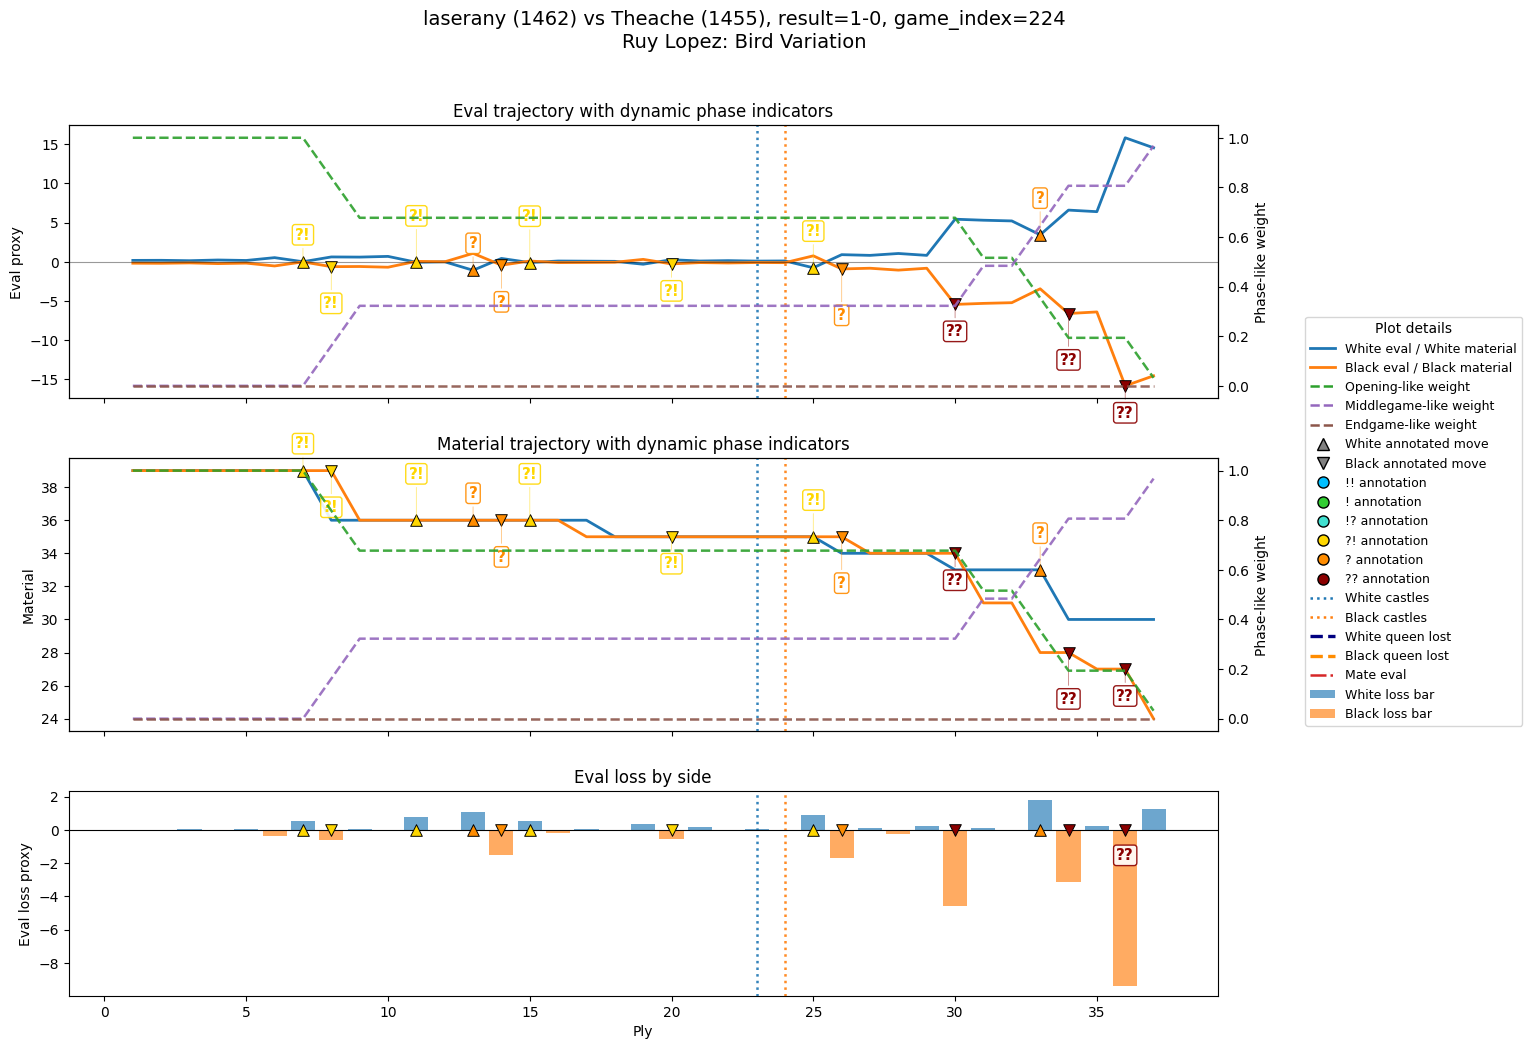

In [119]:
plot_df = plot_game_diagnostics(
  df_plies_feat=df_plies_feat,
  df_games=df_games,
  game_pos=9,
)

In [71]:
plot_df[
  plot_df[
    [
      "is_annotated_move",
      "is_castle",
      "queen_lost",
      "is_mate_eval",
    ]
  ].any(axis=1)
][
  [
    "ply",
    "move_number",
    "side",
    "san_raw",
    "move_annotation",
    "eval_proxy",
    "white_material",
    "black_material",
    "opening_like_weight",
    "middlegame_like_weight",
    "endgame_like_weight",
    "is_castle",
    "queen_lost",
    "is_mate_eval",
  ]
]

,ply,move_number,side,san_raw,move_annotation,eval_proxy,white_material,black_material,opening_like_weight,middlegame_like_weight,endgame_like_weight,is_castle,queen_lost,is_mate_eval
7,8,4,black,g6?!,?!,0.37,39,39,1.000000,0.000000,0.000000,False,False,False
11,12,6,black,O-O,NaN,-0.04,39,39,1.000000,0.000000,0.000000,True,False,False
16,17,9,white,O-O,NaN,-0.05,39,39,1.000000,0.000000,0.000000,True,False,False
22,23,12,white,Re1?!,?!,-0.27,39,39,1.000000,0.000000,0.000000,False,False,False
34,35,18,white,Kg1?!,?!,-0.76,31,31,0.354839,0.645161,0.000000,False,False,False
39,40,20,black,Qxd4,NaN,-0.32,16,25,0.000000,0.764977,0.235023,False,True,False
40,41,21,white,exd4,NaN,-0.41,16,16,0.000000,0.000000,1.000000,False,True,False
50,51,26,white,Rb8?!,?!,-1.10,10,11,0.000000,0.000000,1.000000,False,False,False
52,53,27,white,Rb7?!,?!,-1.71,10,11,0.000000,0.000000,1.000000,False,False,False
54,55,28,white,Rb8?!,?!,-2.12,10,11,0.000000,0.000000,1.000000,False,False,False
